# Section 7: Epigenomic QTL and their target regions

This notebook documents our fine-mapping results from epigenomics context.

The steps are:

1. Load the flattened table generated in section 1, determined the region of interested to exam the fsusie result
2. Load and process the needed data, including the fsusie effect df
3. Plot and adjust the windows to polish the fsusie case study plot

From this notebook, you will obtain 2 outputs:
1. A fsusie exploratory plot showing: the location of the effect, the position of the AD CS, the position of the epi-QTL CS
2. A zoomed-in fsusie exploratory plot


## Define gene to investigate 


In [1]:
source('../../codes/utilis.R')
gene_name = 'BIN1'

tar_gene_info <- get_gene_info(gene_name = gene_name)
gene_id <- tar_gene_info$gene_info$region_id

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors



Attaching package: ‘data.table’




The following objects are masked from ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year




The following objects are masked from ‘package:dplyr’:

    between, first, last




The following object is masked from ‘package:purrr’:

    transpose





Attaching package: ‘cowplot’




The following object is masked from ‘package:lubridate’:

    stamp




## Read the flatten table and effect table 

In [2]:
flatten_table = readRDS(paste0('Fungen_xQTL_allQTL.overlapped.gwas.export.',gene_name,'.rds'))
effect_table_bulk=  read_delim("/data/analysis_result/finemapping_twas/fsusie/export/summary/FunGen_xQTL_epi.bulk.exported.bed.gz")
effect_table_snatac =  read_delim("/data/analysis_result/snatac_fsusie/top_loci/ROSMAP_Kelis_snatac_fsusie.exported.toploci.bed.gz")


Rows: 234407 Columns: 21


── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (13): #chr, a1, a2, variant_ID, event_ID, region_ID, cs_id, cs_root, gri...
dbl  (8): start, end, maf, PIP, cs_coverage_0.95, TADB_start, TADB_end, grid...



ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


Rows: 554 Columns: 21


── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (13): #chr, a1, a2, variant_ID, event_ID, region_ID, cs_id, cs_root, epi...
dbl  (8): start, end, TADB_start, TADB_end, maf, PIP, cs_coverage_0.95, grid...



ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


## First see if there is AD sharing with epi-regional QTL with this gene

In [3]:
flatten_table %>%
  group_by(`#chr`, end) %>%
  filter(any(str_detect(context, "mQTL") | str_detect(context, "haQTL") | str_detect(context, "snATA")), 
         any(str_detect(context, "AD_")))

#chr,start,end,a1,a2,variant_ID,gene_ID,event_ID,cs_coverage_0.95,cs_coverage_0.7,cs_coverage_0.5,PIP,conditional_effect,context,resource,lfsr,z
<int>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>


In [4]:
effect_table = bind_rows(effect_table_bulk,effect_table_snatac)

In [5]:
effect_table%>%colnames

[1] "#chr"               "start"              "end"               
 [4] "a1"                 "a2"                 "variant_ID"        
 [7] "event_ID"           "region_ID"          "maf"               
[10] "PIP"                "cs_coverage_0.95"   "TADB_start"        
[13] "TADB_end"           "grid_resolution"    "cs_id"             
[16] "cs_root"            "grid_positions"     "grid_effects"      
[19] "epi_mark_positions" "epi_mark_names"     "epi_mark_effects"

## Check the epi-QTL that shared variants with an eQTL/sQTL/pQTL of this gene
the column n in the following table show the number of snp in the cs that are shared with the eQTL/sQTL/pQTL of our gene of interest, any QTL with the same ENSG ID will be considered 

In [6]:
flatten_table_variants <- flatten_table%>%filter(str_detect(gene_ID,"chr"))%>%summarize(max = max(end),min = min(end),chr = max( `#chr`)) 

In [7]:
flatten_table_variants

max,min,chr
<int>,<int>,<int>
127135234,127088380,2


In [8]:
effect_table%>%filter(variant_ID %in% flatten_table$variant_ID)%>%count(event_ID)

event_ID,n
<chr>,<int>
KnightADRC_mQTL,120
MSBB_mQTL,71
ROSMAP_DLPFC_mQTL,21
ROSMAP_snATAC_Kelis_Exc,2


In [9]:
effect_of_interest = effect_table%>%filter(variant_ID %in% flatten_table$variant_ID)%>%rename(context = event_ID,gene_ID = region_ID)

## Generate a crude plot to determined whether the story is interesting
This is a crude version of the case study plot which shows the 

fsusie Effect (steelblue line), the gene body (black arrow), the epi-QTL (large steelblue dots), the epi marks (the black dots) and ADGWAS cs position (small red dots), x axis shows the genomics position of each plot, y axis shows estimated effect of the small dots and line, as well as PIP of the epigenetics-QTLs. Only the effect where the AD signal is covered is shown.



In [10]:
effect_of_interest_grid = effect_of_interest %>%
separate_rows(grid_positions, grid_effects, sep = ";")%>%select(-epi_mark_positions,-epi_mark_names ,-epi_mark_effects )%>%
mutate(grid_positions = as.numeric(grid_positions),
       grid_effects = as.numeric(grid_effects),
       cs_coverage_0.95 = as.character(cs_coverage_0.95)
      
      )%>%na.omit


In [11]:
effect_of_interest_mark  = effect_of_interest %>%select(-grid_positions,-grid_effects )%>%
separate_rows(epi_mark_positions,epi_mark_names ,epi_mark_effects , sep = ";")%>%
mutate(epi_mark_positions = as.numeric(epi_mark_positions),
       epi_mark_effects = as.numeric(epi_mark_effects),
       cs_coverage_0.95 = as.character(cs_coverage_0.95)
      
      )%>%na.omit



In [12]:
all_pos = c(flatten_table%>%filter( str_detect(context,"AD_")   , cs_coverage_0.95 != 0  )%>%pull(end),
            tar_gene_info$gene_info$gene_start,tar_gene_info$gene_info$gene_end  )


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


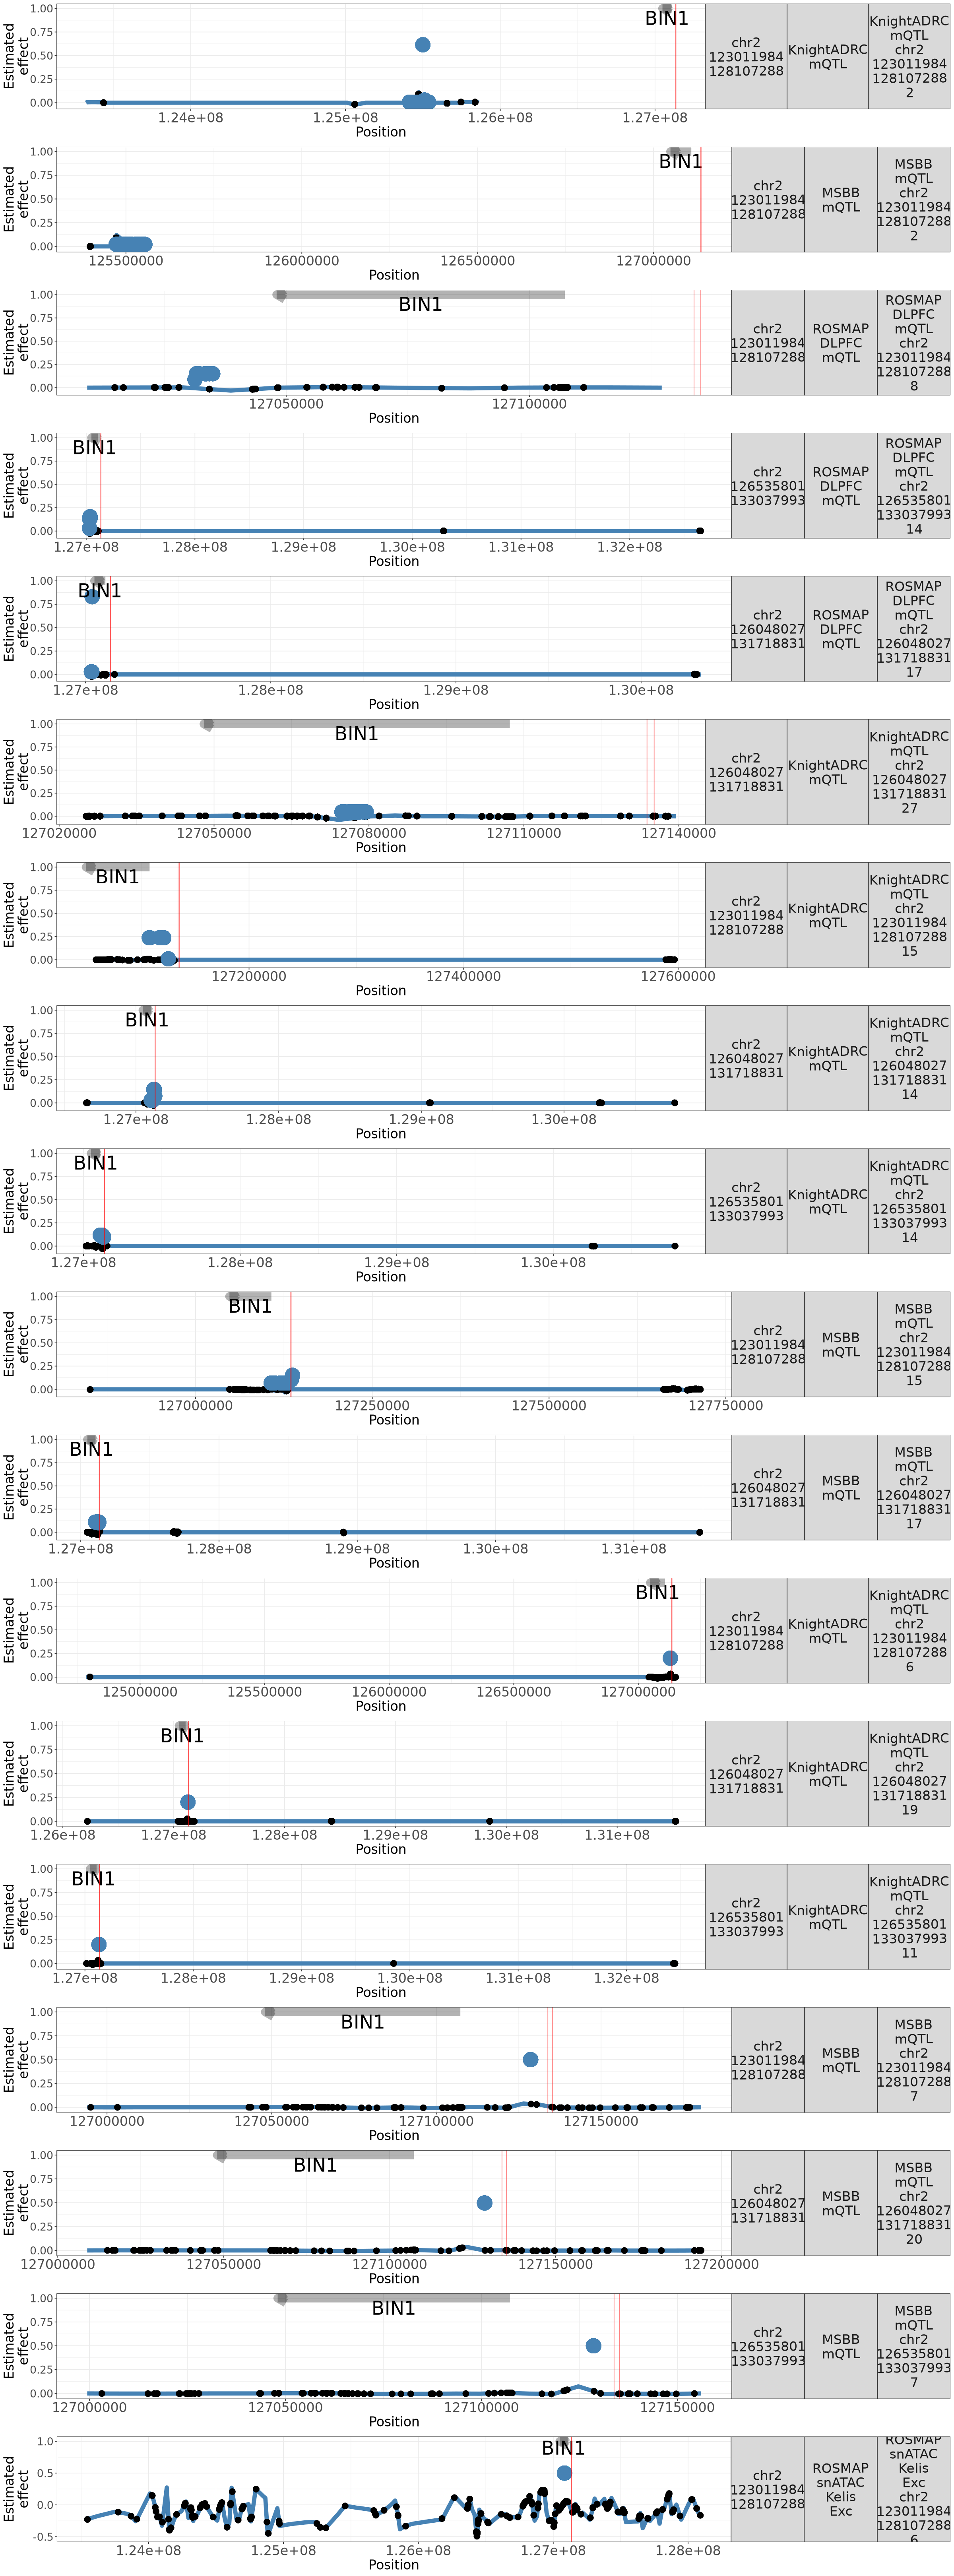

In [13]:
library(dplyr)
library(ggplot2)
library(cowplot)
library(purrr)

keys <- effect_of_interest_grid %>% distinct(cs_id, context, gene_ID)
options(repr.plot.width = 20, repr.plot.height = 3*lengths(keys))

plots <- pmap(keys, function( cs_id, context, gene_ID) {
    cs_id1 = cs_id
  d_grid <- filter(effect_of_interest_grid, cs_id==cs_id1, context==context, gene_ID==gene_ID)
  d_mark <- filter(effect_of_interest_mark, cs_id==cs_id1, context==context, gene_ID==gene_ID)
  ginfo  <- filter(tar_gene_info$gene_info, gene_ID==gene_ID)
  vlines <- flatten_table%>%filter( str_detect(context,"AD_") , cs_coverage_0.95 != 0  )%>%
                                   mutate(AD_context = context%>%str_replace_all("_","\n" ))%>%select(-context,-gene_ID,-cs_coverage_0.95) 
  ggplot() + facet_grid(cs_id + context + gene_ID ~ ., labeller = labeller(.rows = function(x) gsub("([_:,-])", "\n", x)), scale = "free_y") +
    geom_line(data=d_grid, aes(grid_positions, grid_effects, col=cs_coverage_0.95), size=3,,color = "steelblue") +
    geom_point(data=d_mark, aes(epi_mark_positions, epi_mark_effects), color="black", size=4) +
    geom_point(data=d_grid, aes(end, PIP, col=cs_coverage_0.95), size=10,color = "steelblue") +
    geom_segment(data=ginfo, aes(x=gene_start, xend=gene_end, y=1, yend=1),
                 arrow=arrow(length=unit(0.5, "cm")), size=6, alpha=0.3) +
    geom_text(data=ginfo, aes((gene_start+gene_end)/2, 0.9, label=gene_name), size=10) +
    geom_vline(data=vlines, aes(xintercept=end), color="red", alpha=0.5) +
    theme_bw() +
    theme(text = element_text(size = 20), strip.text.y = element_text(size = 20, angle = 0.5), 
            axis.text.x = element_text(size = 20), axis.title.x = element_text(size = 20)) +    labs(x="Position", y="Estimated\neffect")
})

cowplot::plot_grid(plotlist=plots, ncol=1)


Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.”


Warning message:
“Duplicated aesthetics after name standardisation: colour”


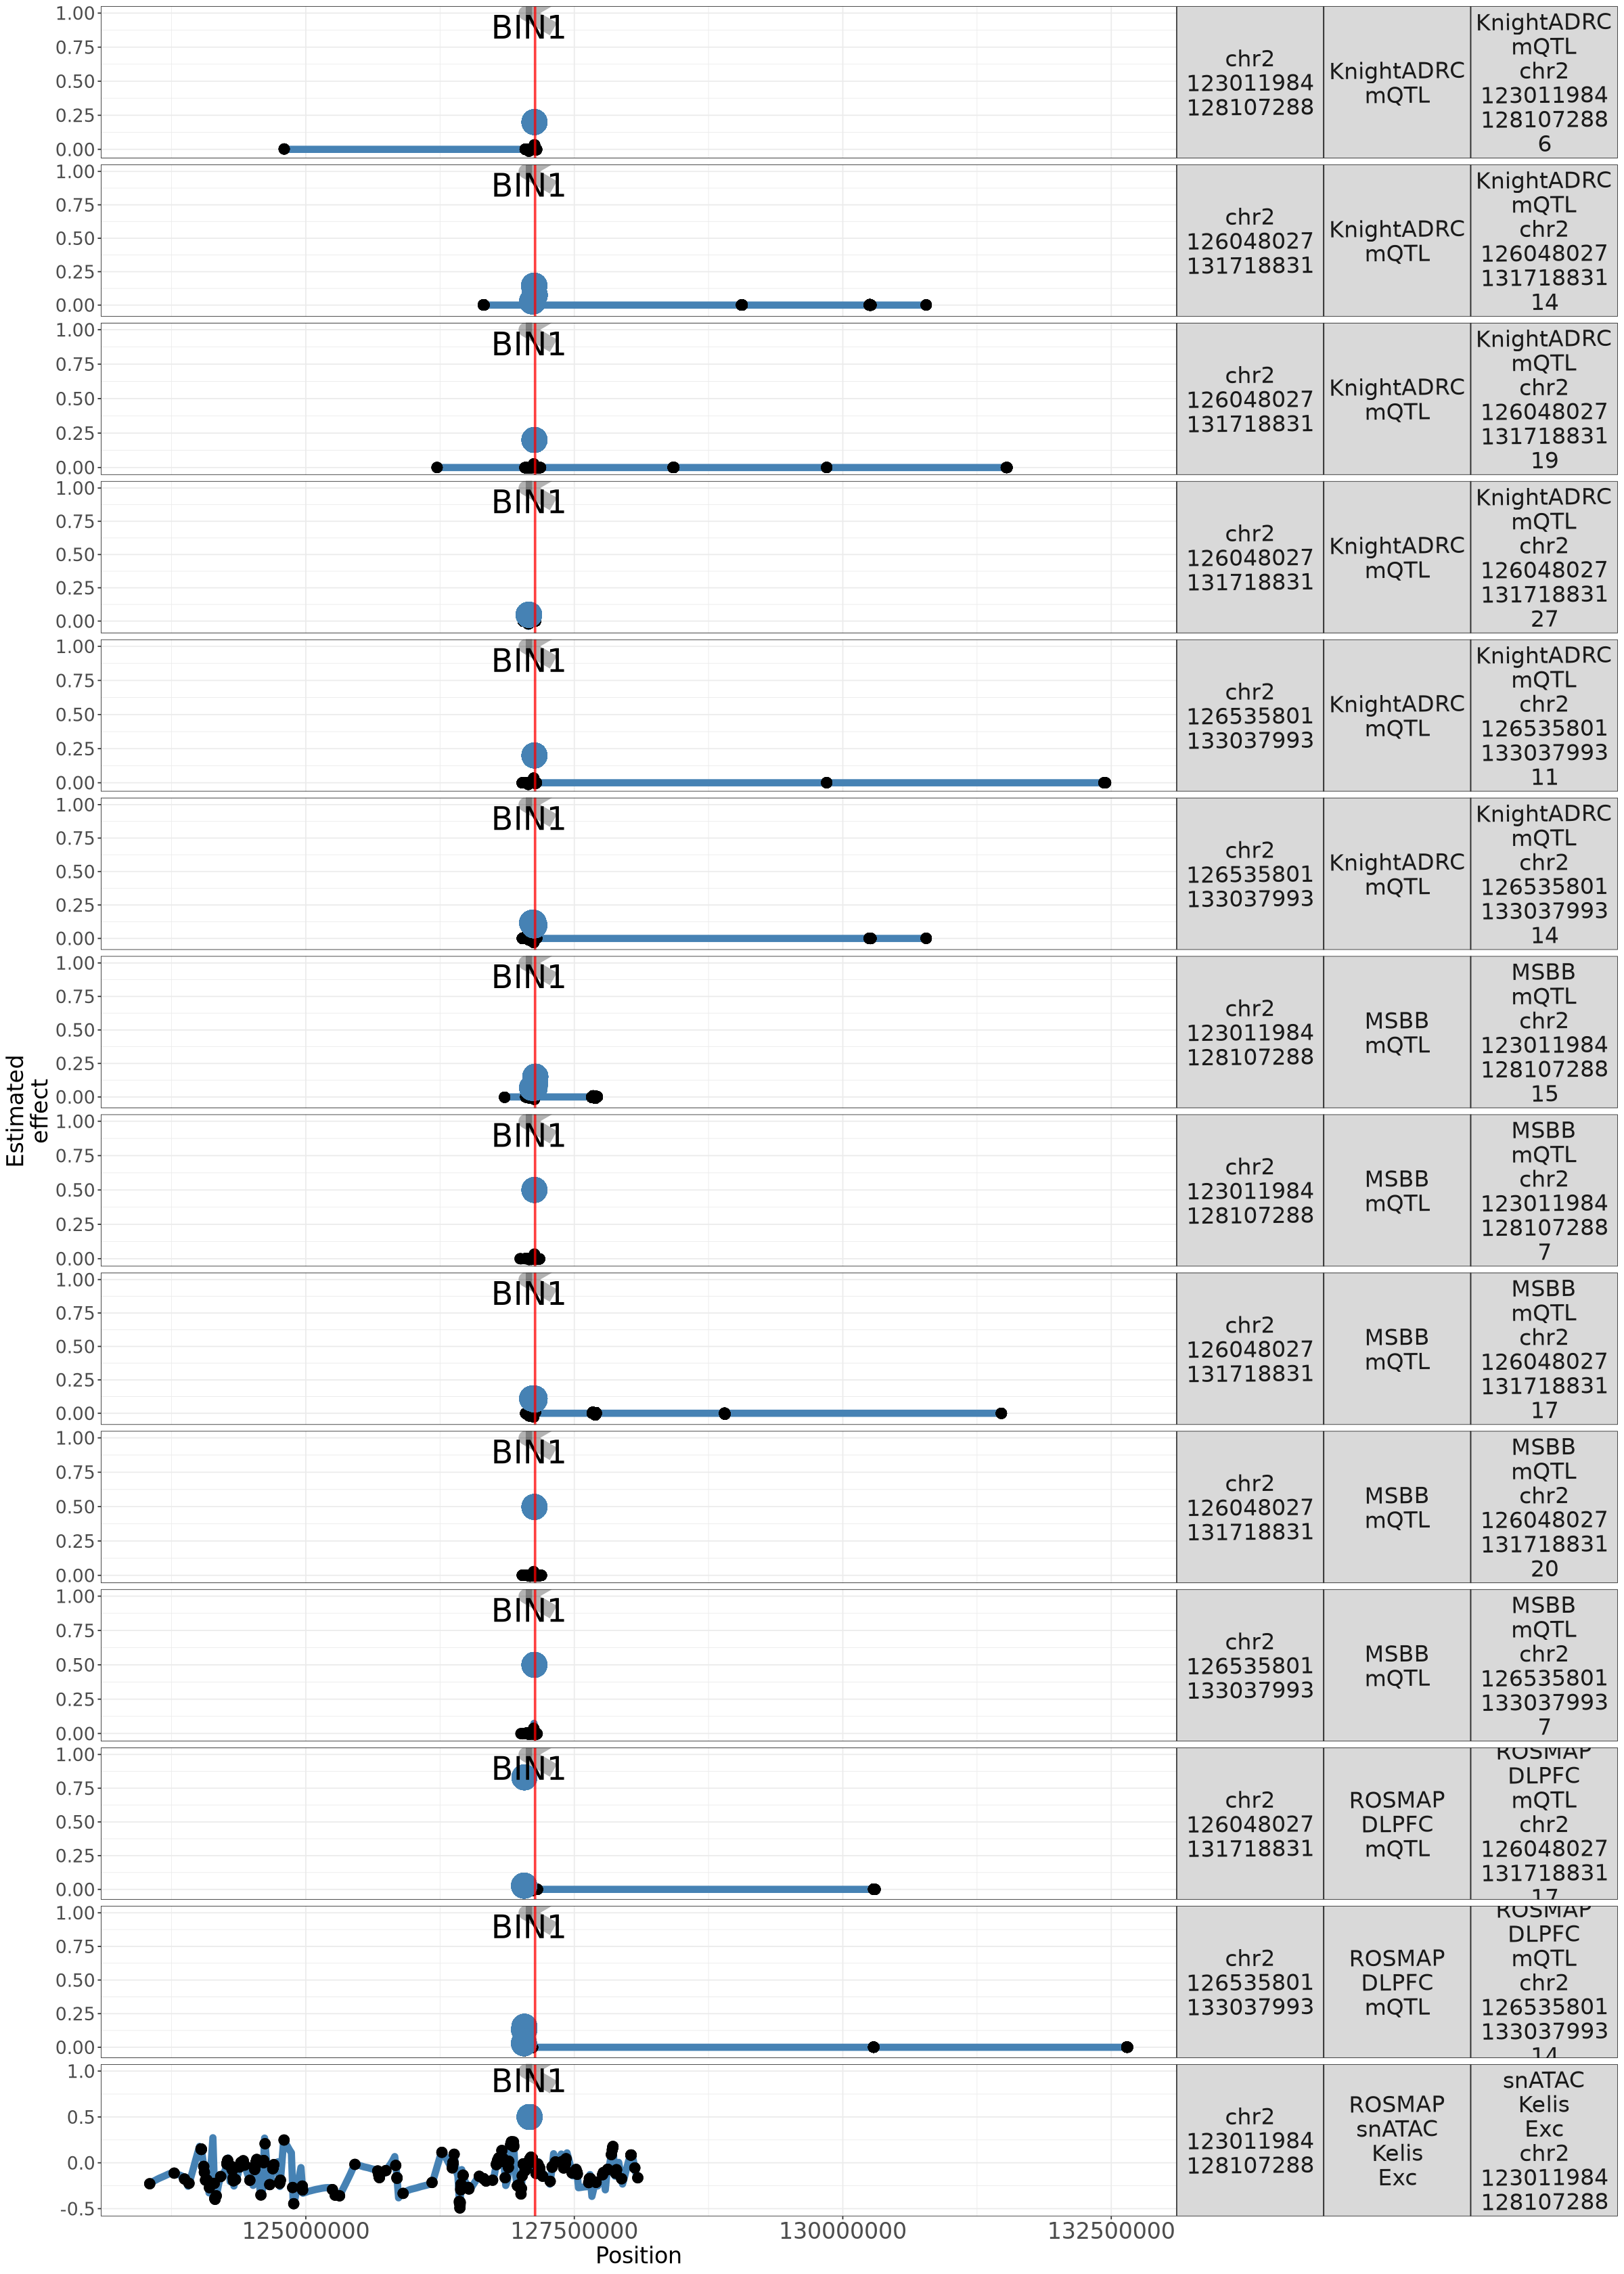

In [14]:
effect_of_interest_grid = effect_of_interest_grid%>%group_by(cs_id)%>%filter(min(grid_positions) < min(all_pos), max(grid_positions) > max(all_pos))
effect_of_interest_mark = effect_of_interest_mark%>%filter(cs_id %in% effect_of_interest_grid$cs_id )
options(repr.plot.width = 20, repr.plot.height = 2* nrow(effect_of_interest_grid%>%count(cs_id , context , gene_ID )))

 ggplot() + theme_bw() + facet_grid(cs_id + context + gene_ID ~ ., labeller = labeller(.rows = function(x) gsub("([_:,-])", "\n", x)), scale = "free_y") +

     # xlim(view_win) +
      ylab("Estimated effect") +
    geom_line(data = effect_of_interest_grid ,
                aes_string(y = "grid_effects", x = "grid_positions"), color = "steelblue",size = 3) +  
        geom_point(data = effect_of_interest_mark,color = "black",
                aes_string(y = "epi_mark_effects", x = "epi_mark_positions"),color = "steelblue", size = 4) +  
    geom_point(data = effect_of_interest_grid ,
                aes_string(y = "PIP", x = "end"),color = "steelblue", size = 10) +
    theme(text = element_text(size = 20), strip.text.y = element_text(size = 20, angle = 0.5), 
            axis.text.x = element_text(size = 20), axis.title.x = element_text(size = 20)) +
      xlab("Position") +
      ylab("Estimated\neffect") +
      geom_segment(arrow = arrow(length = unit(1, "cm")), aes(x = gene_start, xend = gene_end, y = 1, yend = 1), size = 6,
                  data = tar_gene_info$gene_info, alpha = 0.3) +
      geom_text(aes(x = (gene_start + gene_end) / 2, y = 0.9 , label = gene_name), size = 10, 
              data = tar_gene_info$gene_info)+
        geom_vline(aes(xintercept = end  ),size = 1,alpha = 0.5
                   ,color = "red", data = flatten_table%>%filter( str_detect(context,"AD_") , cs_coverage_0.95 != 0  )%>%
                                   mutate(AD_context = context%>%str_replace_all("_","\n" ))%>%select(-context,-gene_ID,-cs_coverage_0.95) ) 